# 01 — EDA: Customer Churn Model

**Dataset:** Panel longitudinal — observaciones mensuales por cliente  
**Target:** `churn` (binario, 0/1)  
**Período:** Enero 2023 → Diciembre 2026  

---

**Índice**
1. Setup y carga
2. Estructura del dataset
3. Calidad de datos
4. Análisis del target
5. Variables numéricas
6. Variables categóricas
7. Análisis temporal
8. Outliers
9. Hallazgos y decisiones de diseño

## 1. Setup y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13

RAW_PATH      = '../data/raw/customer_churn_simulated.csv'
FIGURES_PATH  = '../artifacts/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

NUM_COLS = [
    'tenure_months', 'age', 'monthly_charges', 'usage_minutes',
    'support_calls', 'complaints_last_3m', 'late_payments',
    'marketing_emails_opened', 'active_days_last_month'
]
CAT_COLS = ['region', 'contract_type', 'payment_method']

In [2]:
df = pd.read_csv(RAW_PATH, parse_dates=['period'])
print(f'Shape: {df.shape}')
df.head()

Shape: (480000, 15)


,customer_id,period,tenure_months,age,monthly_charges,usage_minutes,support_calls,complaints_last_3m,late_payments,marketing_emails_opened,active_days_last_month,region,contract_type,payment_method,churn
0,C0000001,2023-01-01,1,42,59.63,345.1,1,0,0,8,14,Lima,Monthly,Debit,0
1,C0000002,2023-01-01,1,36,59.94,331.8,0,0,0,2,9,International,Enterprise,CreditCard,1
2,C0000003,2023-01-01,1,44,61.52,304.4,0,1,0,2,9,South,Annual,Debit,0
3,C0000004,2023-01-01,1,53,77.23,409.4,0,0,0,2,20,East,Annual,Cash,0
4,C0000005,2023-01-01,1,35,91.60,353.4,1,1,1,4,26,South,Enterprise,Cash,0


## 2. Estructura del dataset

In [3]:
print('=== Vista general ===')
print(f'Observaciones totales : {len(df):>10,}')
print(f'Clientes únicos       : {df["customer_id"].nunique():>10,}')
print(f'Períodos únicos       : {df["period"].nunique():>10}')
print(f'Rango temporal        : {df["period"].min().date()} → {df["period"].max().date()}')
print(f'Columnas              : {df.shape[1]}')
print()
print('Tipos de datos:')
print(df.dtypes)

=== Vista general ===
Observaciones totales :    480,000
Clientes únicos       :     51,245
Períodos únicos       :         48
Rango temporal        : 2023-01-01 → 2026-12-01
Columnas              : 15

Tipos de datos:
customer_id                           str
period                     datetime64[us]
tenure_months                       int64
age                                 int64
monthly_charges                   float64
usage_minutes                     float64
support_calls                       int64
complaints_last_3m                  int64
late_payments                       int64
marketing_emails_opened             int64
active_days_last_month              int64
region                                str
contract_type                         str
payment_method                        str
churn                               int64
dtype: object


Observaciones por cliente:
count    51245.0
mean         9.4
std          8.3
min          1.0
25%          3.0
50%          7.0
75%         13.0
max         48.0
dtype: float64

⚠ Clientes con 1 sola obs: 5141
✓ Clientes con 48 obs (full): 120


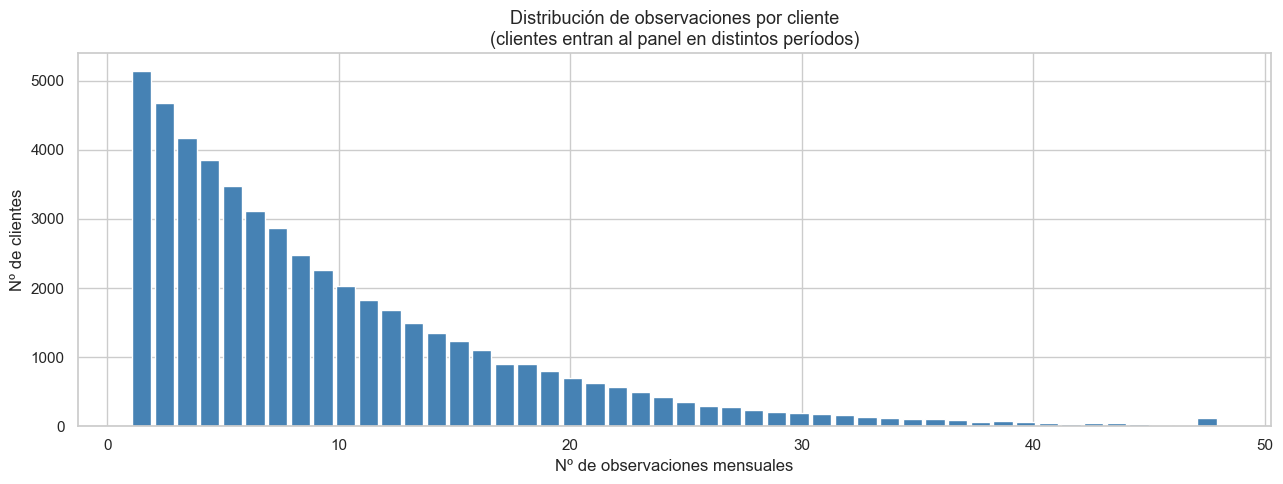

In [4]:
# Observaciones por cliente — distribución desigual: dato clave para el split temporal
obs_per_customer = df.groupby('customer_id').size()
print('Observaciones por cliente:')
print(obs_per_customer.describe().round(1))
print(f'\n⚠ Clientes con 1 sola obs: {(obs_per_customer == 1).sum()}')
print(f'✓ Clientes con 48 obs (full): {(obs_per_customer == 48).sum()}')

fig, ax = plt.subplots()
obs_per_customer.hist(bins=48, ax=ax, color='steelblue', edgecolor='white', rwidth=0.85)
ax.set_xlabel('Nº de observaciones mensuales')
ax.set_ylabel('Nº de clientes')
ax.set_title('Distribución de observaciones por cliente\n(clientes entran al panel en distintos períodos)')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}obs_per_customer.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Calidad de datos

In [5]:
# Nulos
nulls = df.isnull().sum()
print(f'Nulos totales: {nulls.sum()}')
if nulls.sum() == 0:
    print('✓ Dataset sin valores nulos')
else:
    print(nulls[nulls > 0])

Nulos totales: 0
✓ Dataset sin valores nulos


In [6]:
# Duplicados
dup_total = df.duplicated().sum()
dup_keys  = df.duplicated(subset=['customer_id', 'period']).sum()
print(f'Filas duplicadas: {dup_total}')
print(f'Duplicados (customer_id + period): {dup_keys}')
if dup_total == 0:
    print('✓ Sin duplicados')

Filas duplicadas: 0
Duplicados (customer_id + period): 0
✓ Sin duplicados


In [7]:
# Coherencia del target — ¿puede un cliente churnar más de una vez?
churn_per_customer = df.groupby('customer_id')['churn'].sum()
print('Distribución de eventos de churn por cliente:')
print(churn_per_customer.value_counts().to_frame('clientes'))
print(f'\nMáx churns por cliente: {churn_per_customer.max()}')
print()
print('✓ Cada cliente tiene como máximo 1 evento de churn.')
print('  → El churn es un evento terminal: una vez que ocurre, el cliente no reaparece.')
print('  → Modelar a nivel de OBSERVACIÓN, con cuidado de no filtrar por eventos futuros.')

Distribución de eventos de churn por cliente:
       clientes
churn          
1         42165
0          9080

Máx churns por cliente: 1

✓ Cada cliente tiene como máximo 1 evento de churn.
  → El churn es un evento terminal: una vez que ocurre, el cliente no reaparece.
  → Modelar a nivel de OBSERVACIÓN, con cuidado de no filtrar por eventos futuros.


## 4. Análisis del target (churn)

No Churn (0): 437,835  (91.2%)
Churn    (1): 42,165  (8.8%)

Ratio desbalance (0:1) = 10.4x

⚠ Desbalance moderado (~9% churn rate).
  Estrategia: scale_pos_weight en XGBoost/LightGBM, no oversampling agresivo.


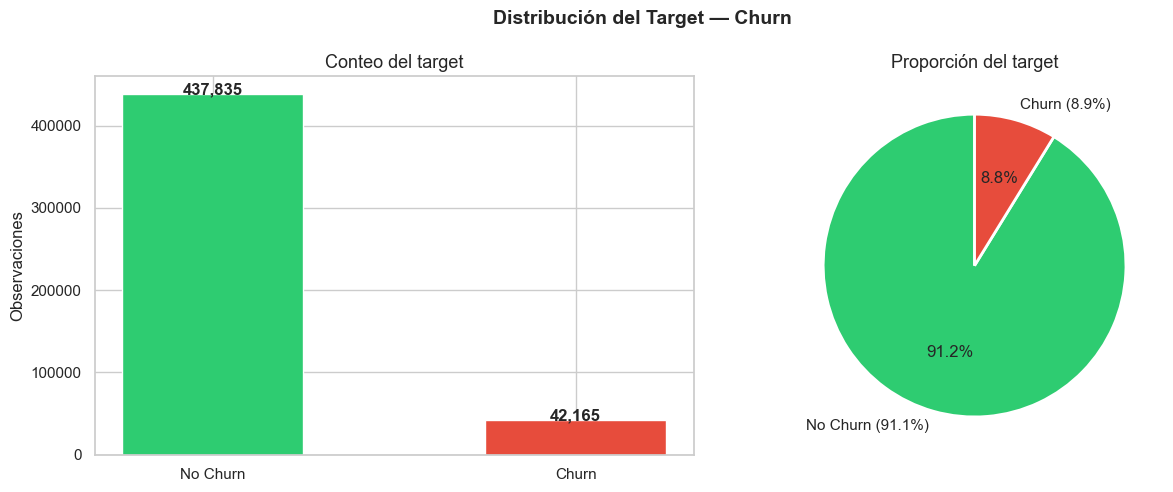

In [8]:
churn_counts = df['churn'].value_counts()
churn_rate   = df['churn'].mean()

print(f'No Churn (0): {churn_counts[0]:,}  ({100-churn_rate*100:.1f}%)')
print(f'Churn    (1): {churn_counts[1]:,}  ({churn_rate*100:.1f}%)')
print(f'\nRatio desbalance (0:1) = {churn_counts[0]/churn_counts[1]:.1f}x')
print()
print('⚠ Desbalance moderado (~9% churn rate).')
print('  Estrategia: scale_pos_weight en XGBoost/LightGBM, no oversampling agresivo.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(['No Churn', 'Churn'], churn_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, v in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Conteo del target')
axes[0].set_ylabel('Observaciones')

axes[1].pie(churn_counts.values, labels=['No Churn (91.1%)', 'Churn (8.9%)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción del target')

plt.suptitle('Distribución del Target — Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

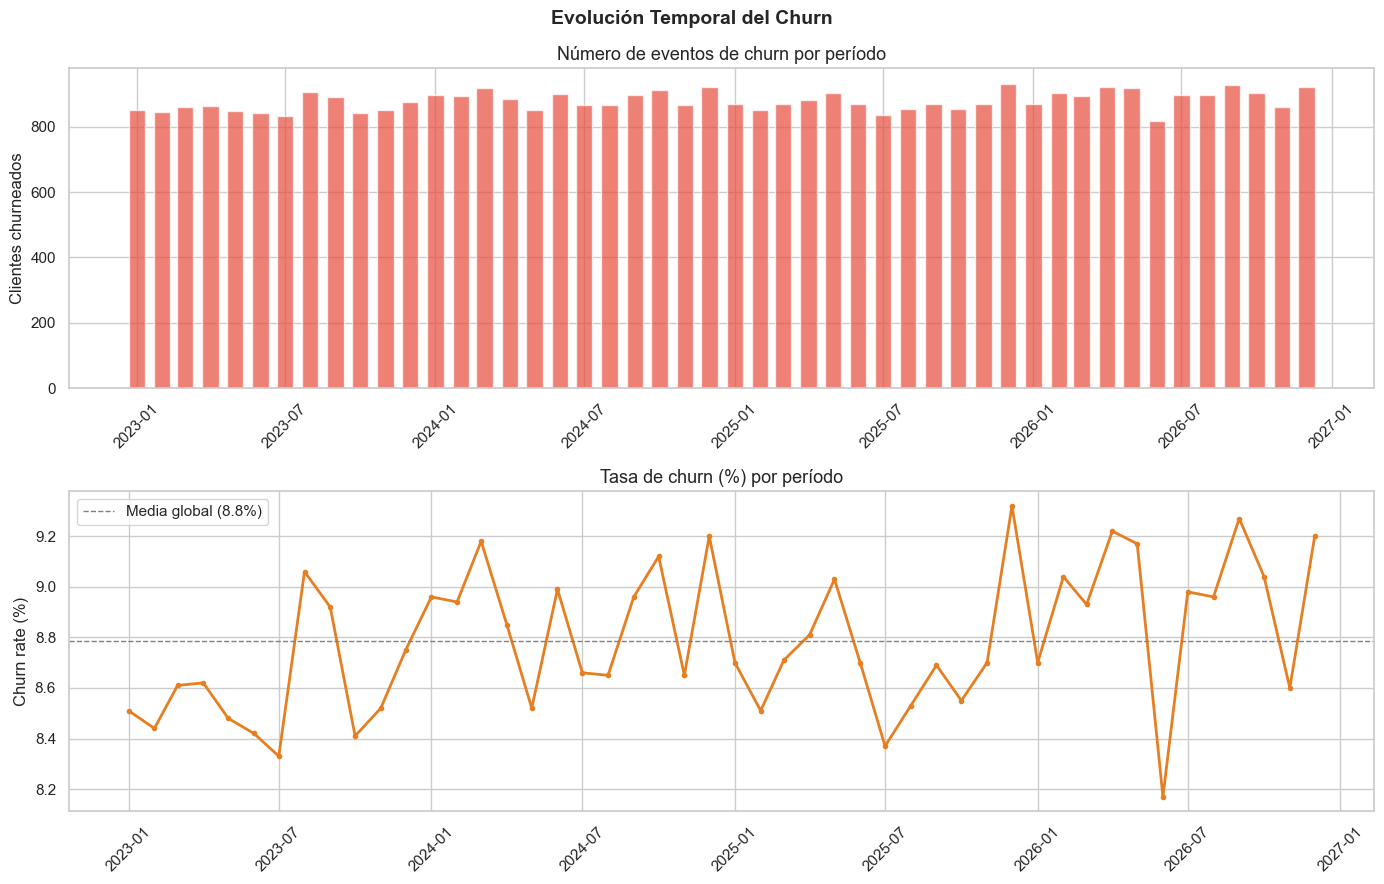


Churn rate mín: 8.17%  (2026-06-01)
Churn rate máx: 9.32%  (2025-12-01)

Nota: períodos recientes tienen menos observaciones (clientes que entraron tarde al panel).


In [9]:
# Evolución temporal del churn
temporal = df.groupby('period')['churn'].agg(['sum','mean','count']).reset_index()
temporal.columns = ['period', 'churn_count', 'churn_rate', 'total_obs']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].bar(temporal['period'], temporal['churn_count'],
            color='#e74c3c', alpha=0.7, width=20)
axes[0].set_title('Número de eventos de churn por período')
axes[0].set_ylabel('Clientes churneados')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(temporal['period'], temporal['churn_rate'] * 100,
             color='#e67e22', linewidth=2, marker='o', markersize=3)
axes[1].axhline(churn_rate * 100, color='gray', linestyle='--', linewidth=1, label=f'Media global ({churn_rate*100:.1f}%)')
axes[1].set_title('Tasa de churn (%) por período')
axes[1].set_ylabel('Churn rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('Evolución Temporal del Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}churn_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nChurn rate mín: {temporal["churn_rate"].min()*100:.2f}%  ({temporal.loc[temporal["churn_rate"].idxmin(), "period"].date()})')
print(f'Churn rate máx: {temporal["churn_rate"].max()*100:.2f}%  ({temporal.loc[temporal["churn_rate"].idxmax(), "period"].date()})')
print(f'\nNota: períodos recientes tienen menos observaciones (clientes que entraron tarde al panel).')

## 5. Variables numéricas

In [10]:
# Estadísticas por grupo churn
stats_by_churn = df.groupby('churn')[NUM_COLS].mean().T.round(3)
stats_by_churn.columns = ['No Churn (0)', 'Churn (1)']
stats_by_churn['Diferencia %'] = ((stats_by_churn['Churn (1)'] - stats_by_churn['No Churn (0)']) 
                                   / stats_by_churn['No Churn (0)'] * 100).round(1)
stats_by_churn = stats_by_churn.sort_values('Diferencia %', ascending=False)
print('=== Medias por grupo — ordenadas por diferencia ===')
print(stats_by_churn.to_string())

=== Medias por grupo — ordenadas por diferencia ===
                         No Churn (0)  Churn (1)  Diferencia %
complaints_last_3m              0.328      0.431          31.4
late_payments                   0.427      0.479          12.2
support_calls                   0.992      1.101          11.0
tenure_months                   8.799      9.050           2.9
age                            37.475     37.525           0.1
monthly_charges                70.646     70.609          -0.1
usage_minutes                 283.397    280.146          -1.1
active_days_last_month         20.735     20.444          -1.4
marketing_emails_opened         2.679      2.503          -6.6


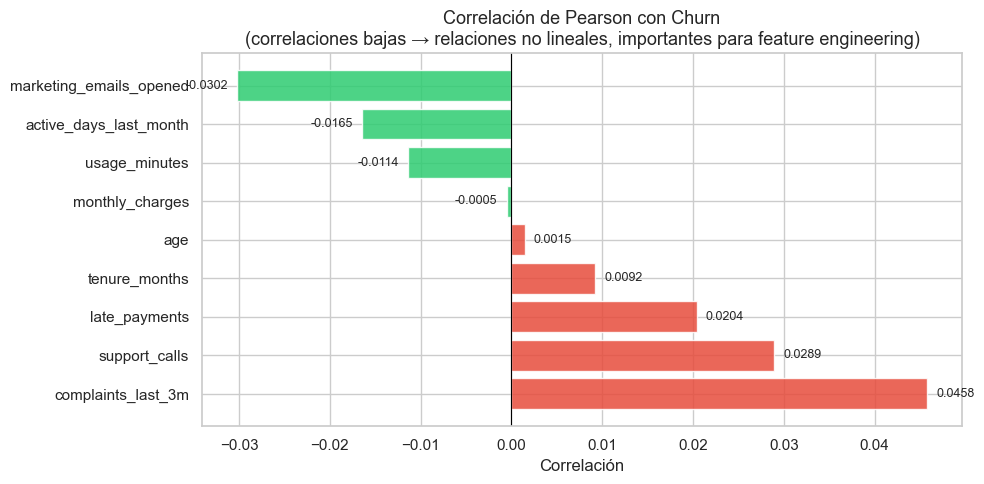

⚠ Correlaciones lineales muy bajas (máx ~0.10).
  → El modelo requiere capturar relaciones NO LINEALES.
  → Prioridad: XGBoost / LightGBM sobre Regresión Logística.
  → Feature engineering (lags, rolling stats) será crítico.


In [11]:
# Correlación lineal con el target
corr_target = df[NUM_COLS + ['churn']].corr()['churn'].drop('churn').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, corr_target.values):
    ax.text(v + (0.001 if v >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_title('Correlación de Pearson con Churn\n(correlaciones bajas → relaciones no lineales, importantes para feature engineering)')
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}feature_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('⚠ Correlaciones lineales muy bajas (máx ~0.10).')
print('  → El modelo requiere capturar relaciones NO LINEALES.')
print('  → Prioridad: XGBoost / LightGBM sobre Regresión Logística.')
print('  → Feature engineering (lags, rolling stats) será crítico.')

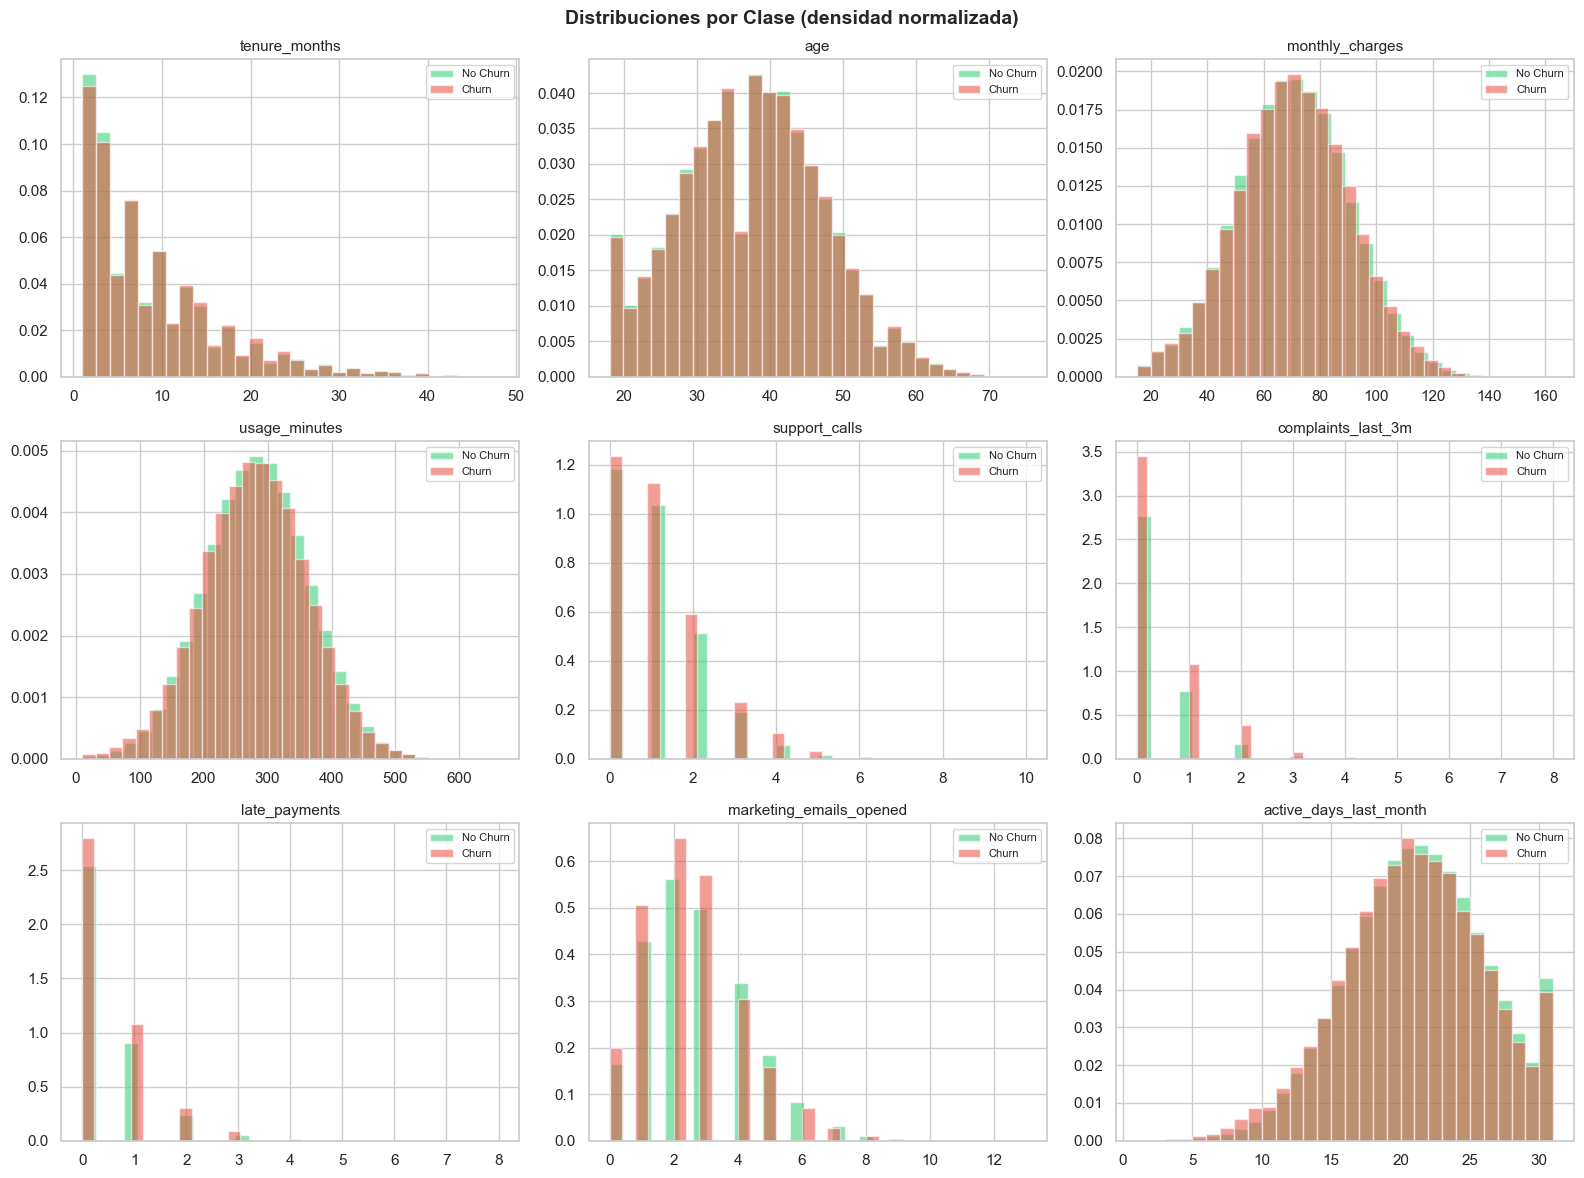

In [12]:
# Distribuciones: churn vs no-churn
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    df[df['churn']==0][col].hist(bins=30, ax=axes[i], alpha=0.55, color='#2ecc71',
                                  label='No Churn', density=True)
    df[df['churn']==1][col].hist(bins=30, ax=axes[i], alpha=0.55, color='#e74c3c',
                                  label='Churn', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuciones por Clase (densidad normalizada)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

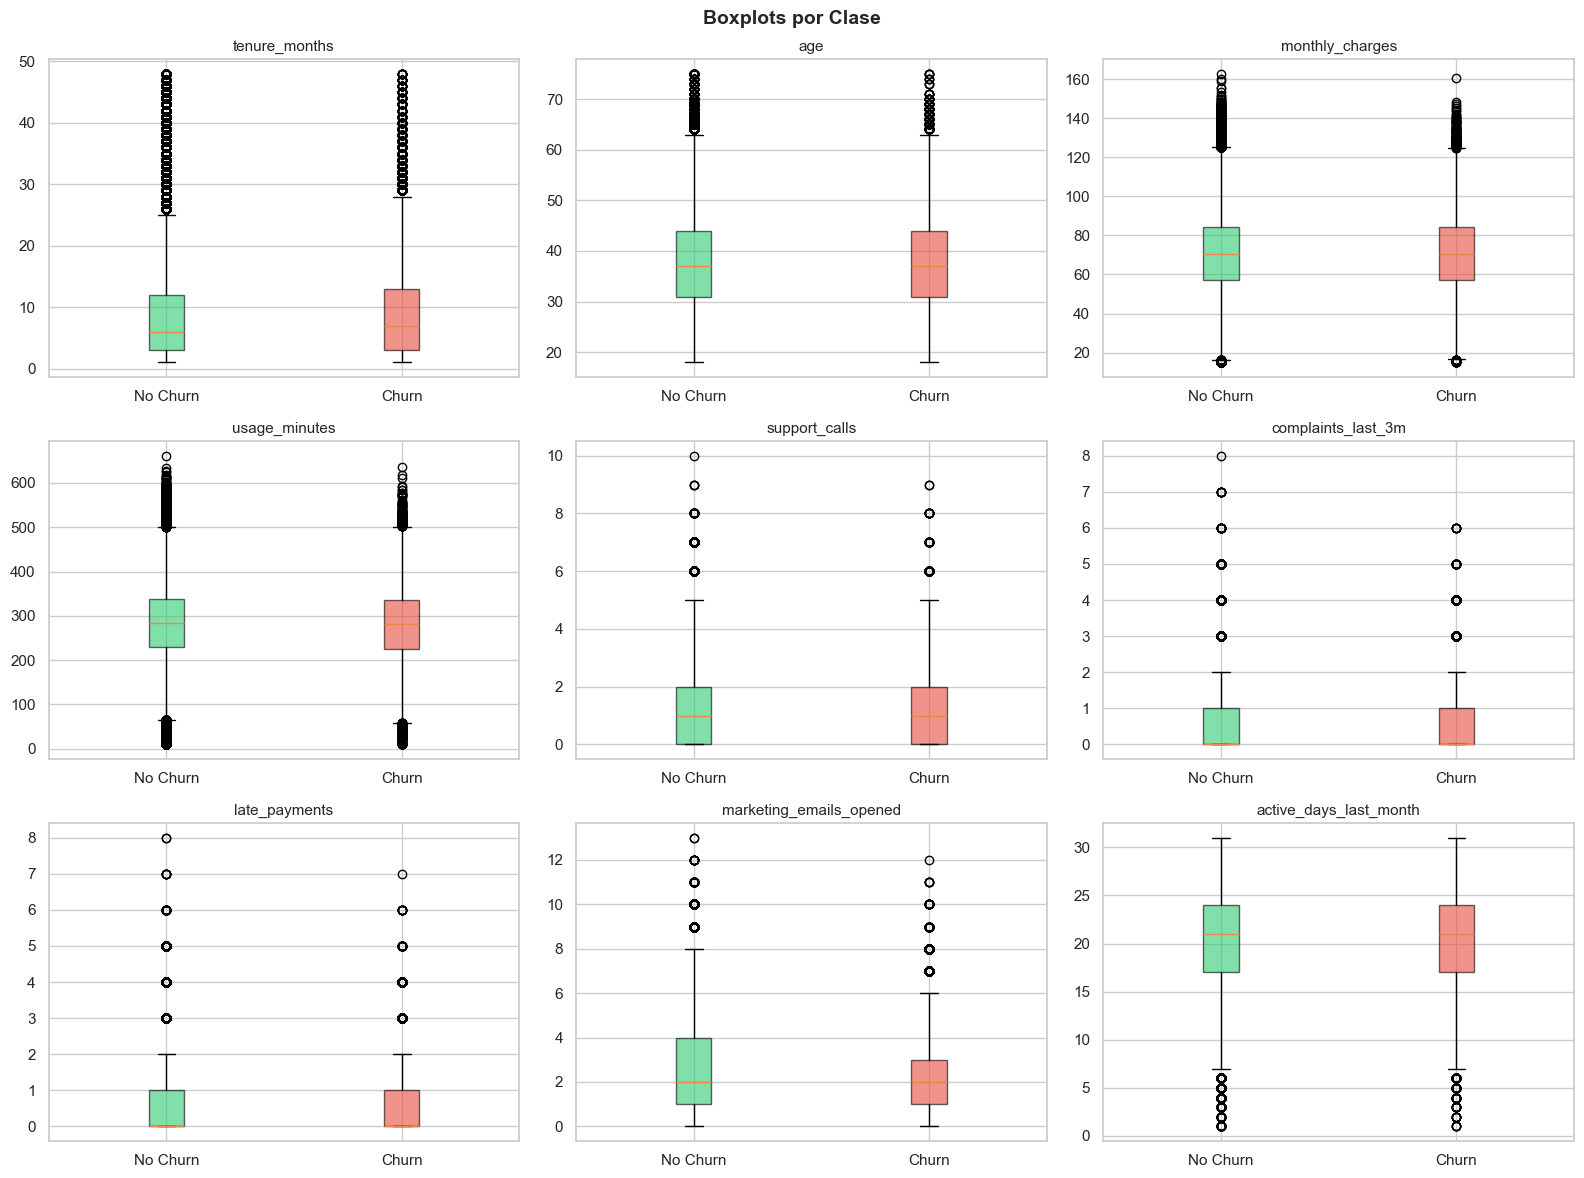

In [13]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    data_0 = df[df['churn']==0][col]
    data_1 = df[df['churn']==1][col]
    bp = axes[i].boxplot([data_0, data_1], labels=['No Churn', 'Churn'],
                          patch_artist=True, notch=False)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.6)
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplots por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}boxplots_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Variables categóricas

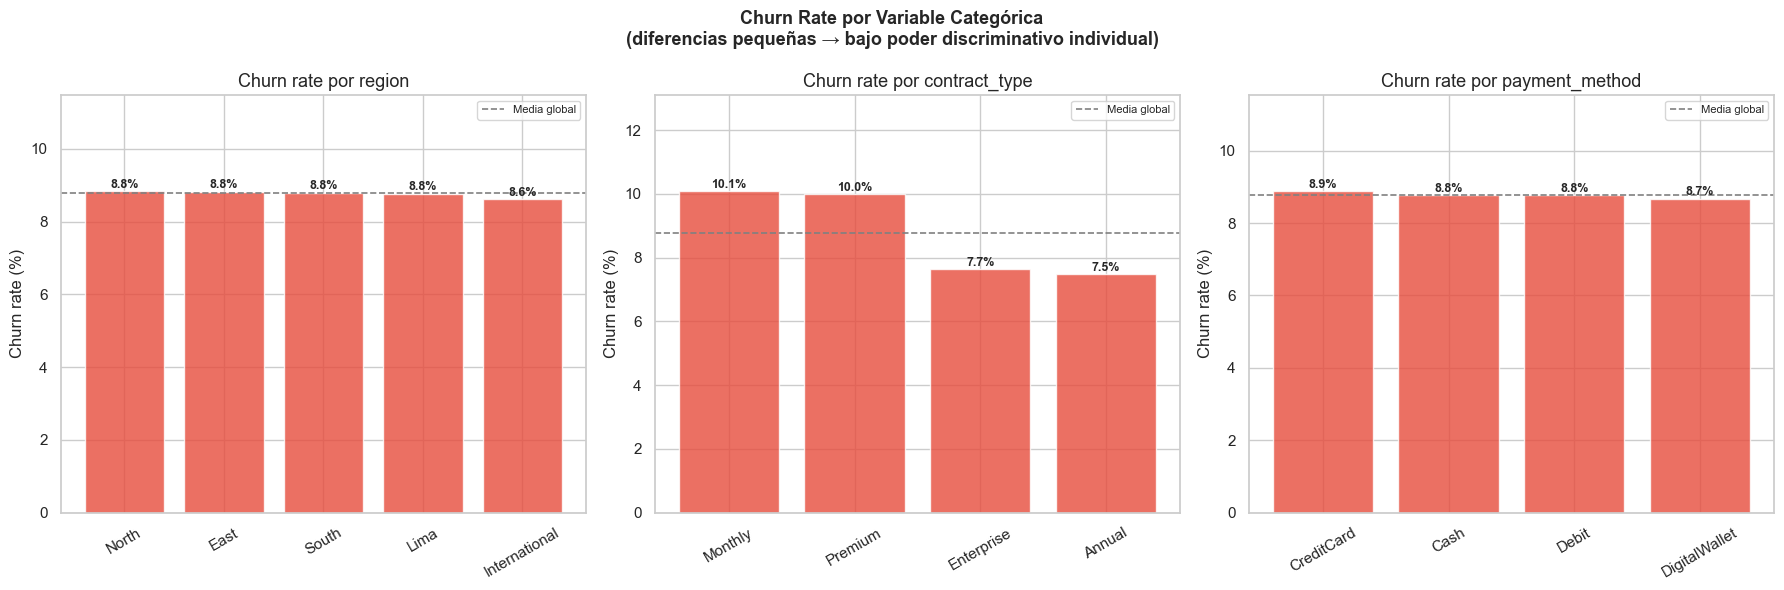

⚠ Diferencias entre categorías son menores a 1.5pp.
  → Las categóricas solas no son discriminativas, pero pueden interactuar con numéricas.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(CAT_COLS):
    churn_rate_cat = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate_cat.index, churn_rate_cat.values * 100,
                       color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[i].axhline(df['churn'].mean() * 100, color='gray', linestyle='--',
                    linewidth=1.2, label='Media global')
    axes[i].set_title(f'Churn rate por {col}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].set_ylim(0, max(churn_rate_cat.values * 100) * 1.3)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, churn_rate_cat.values * 100):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate por Variable Categórica\n(diferencias pequeñas → bajo poder discriminativo individual)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('⚠ Diferencias entre categorías son menores a 1.5pp.')
print('  → Las categóricas solas no son discriminativas, pero pueden interactuar con numéricas.')

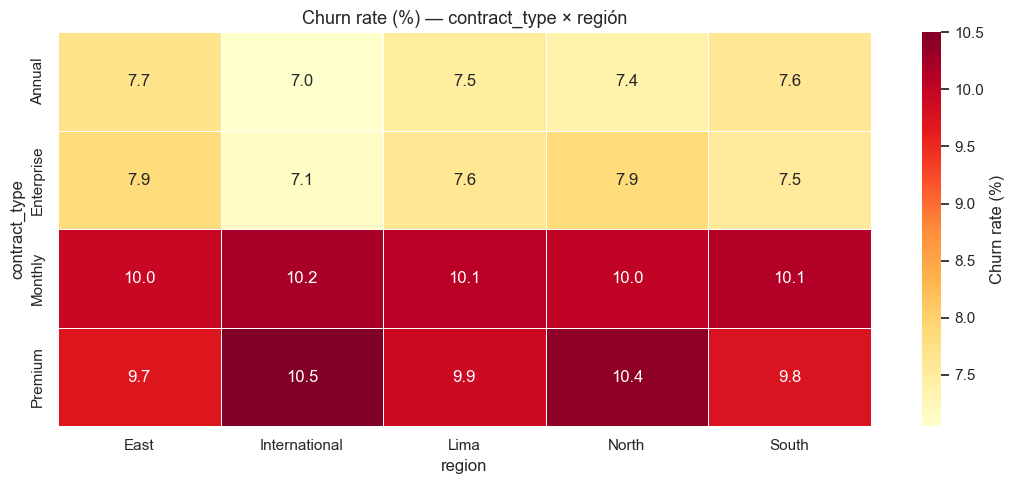

In [15]:
# Heatmap: churn rate por pares de categóricas
pivot = df.groupby(['contract_type', 'region'])['churn'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Churn rate (%)'})
ax.set_title('Churn rate (%) — contract_type × región', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}churn_heatmap_cat.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis temporal

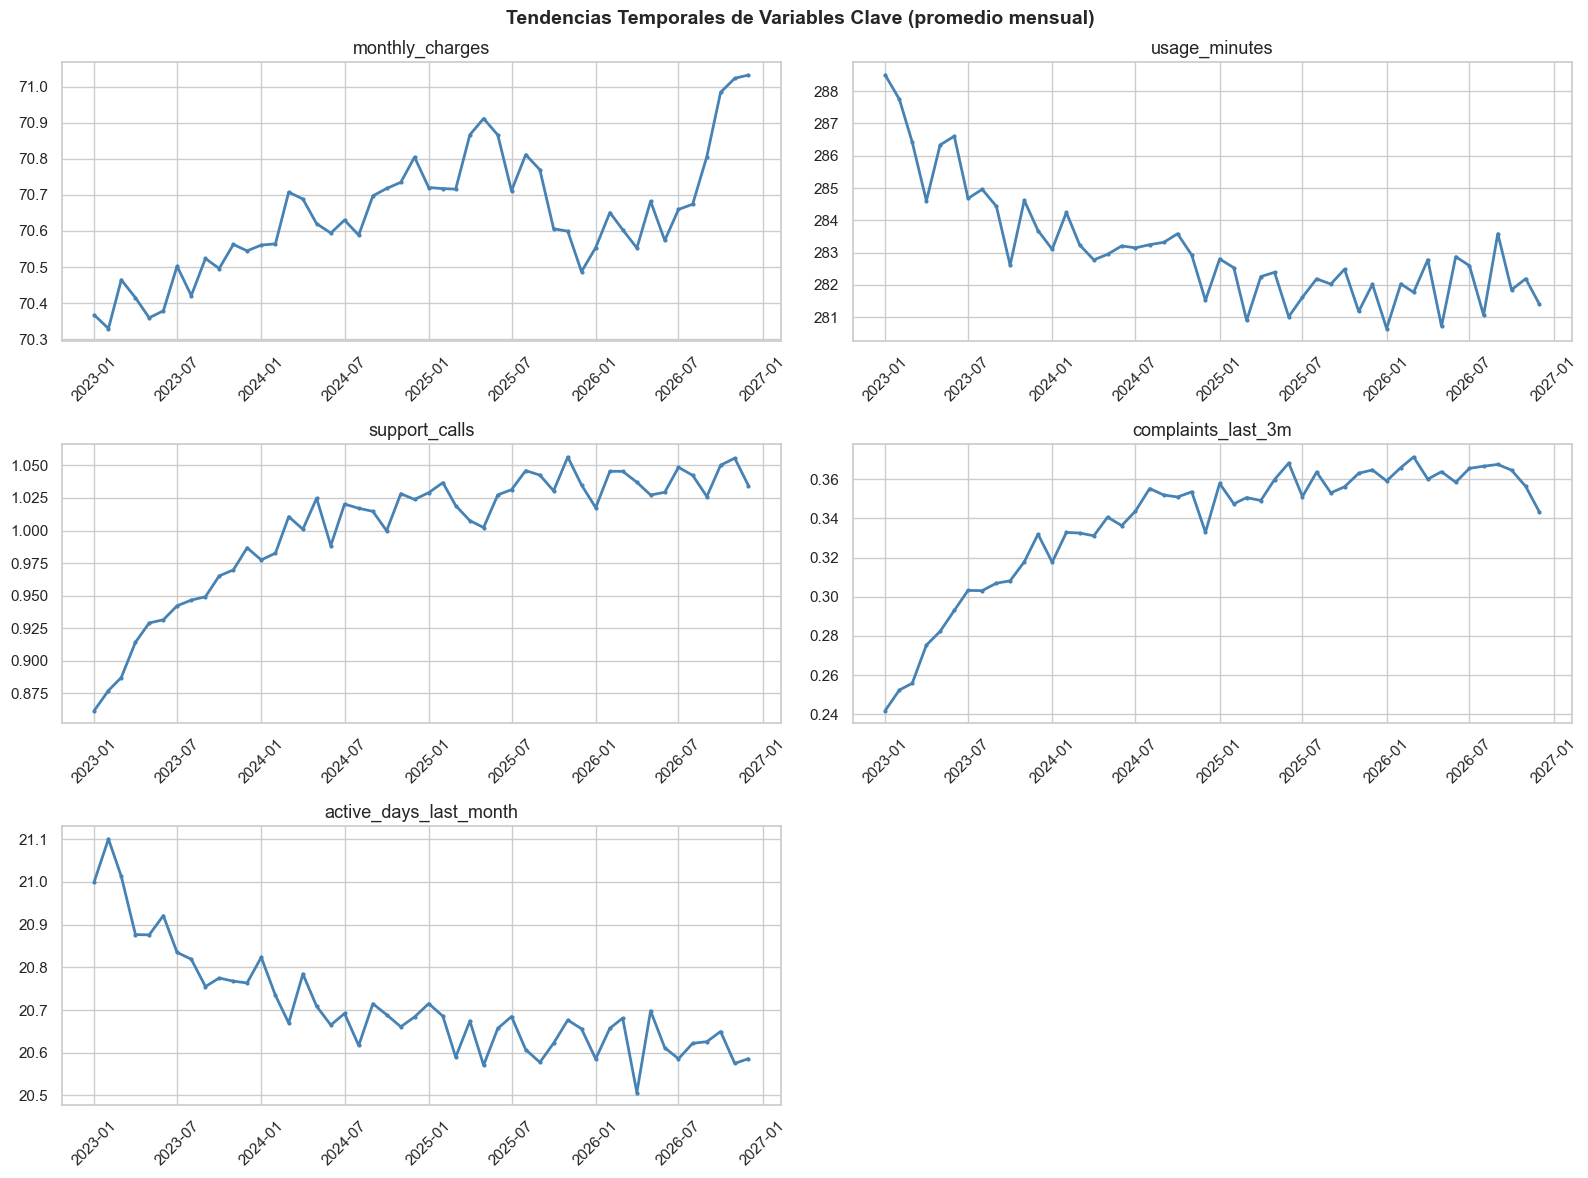

In [16]:
# Tendencias de variables clave en el tiempo
trend_cols = ['monthly_charges', 'usage_minutes', 'support_calls', 'complaints_last_3m', 'active_days_last_month']
temporal_avg = df.groupby('period')[trend_cols].mean()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(trend_cols):
    axes[i].plot(temporal_avg.index, temporal_avg[col], linewidth=2, color='steelblue', marker='o', markersize=2)
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.suptitle('Tendencias Temporales de Variables Clave (promedio mensual)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

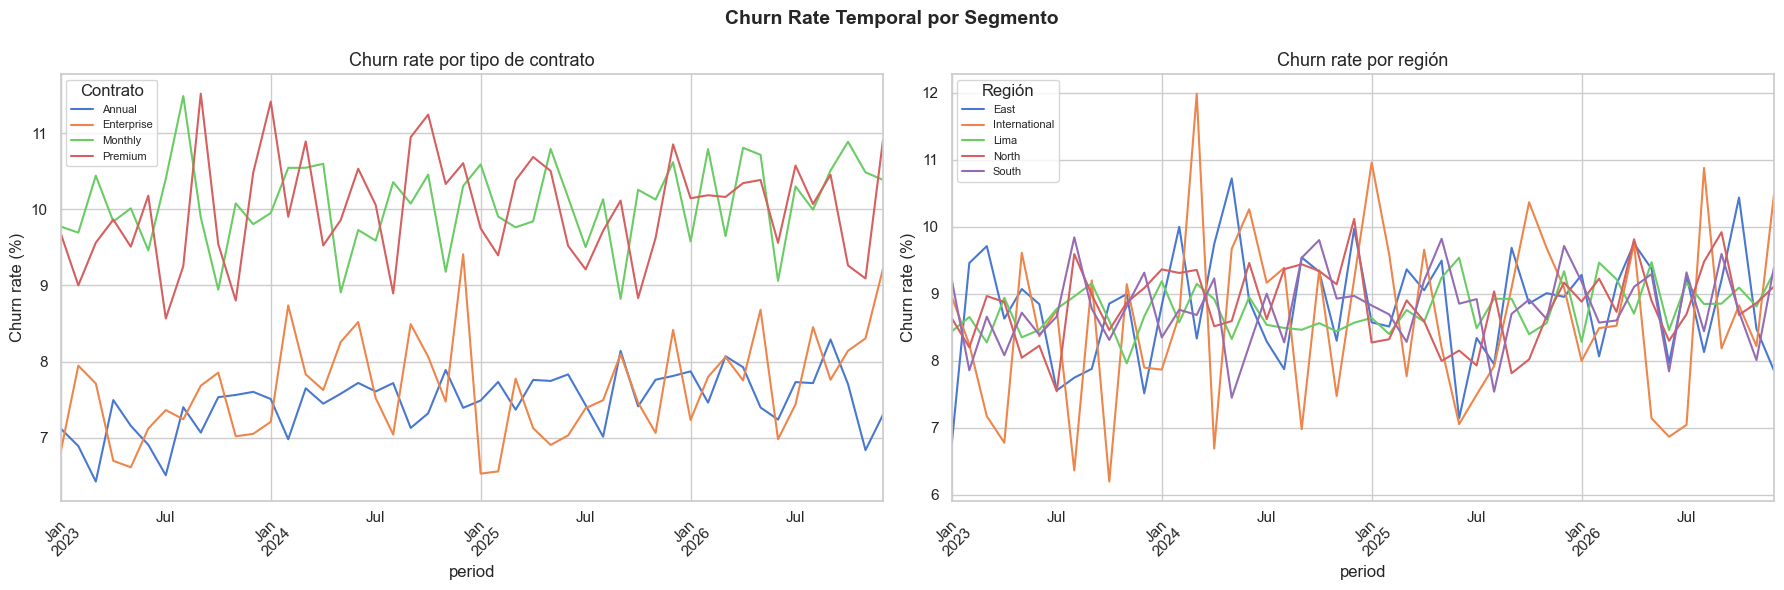

In [17]:
# Churn rate por contract_type en el tiempo
pivot_contract = df.groupby(['period', 'contract_type'])['churn'].mean().unstack() * 100
pivot_region   = df.groupby(['period', 'region'])['churn'].mean().unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pivot_contract.plot(ax=axes[0], linewidth=1.5)
axes[0].set_title('Churn rate por tipo de contrato')
axes[0].set_ylabel('Churn rate (%)')
axes[0].legend(title='Contrato', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

pivot_region.plot(ax=axes[1], linewidth=1.5)
axes[1].set_title('Churn rate por región')
axes[1].set_ylabel('Churn rate (%)')
axes[1].legend(title='Región', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Churn Rate Temporal por Segmento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}churn_by_segment_time.png', dpi=150, bbox_inches='tight')
plt.show()

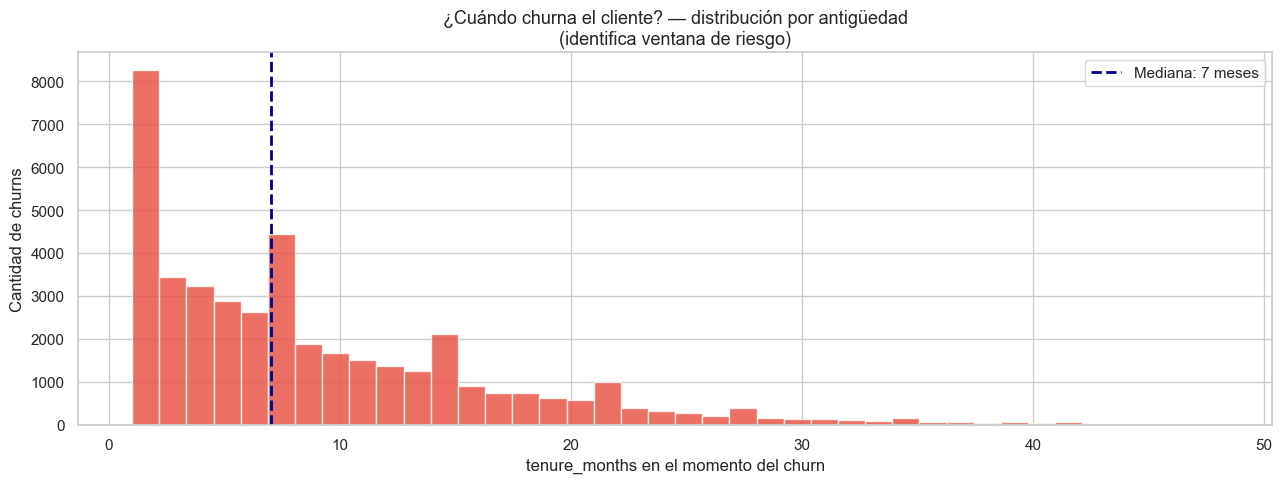

Mediana de tenure al momento del churn: 7 meses
25% percentil: 3 meses
75% percentil: 13 meses


In [18]:
# ¿En qué mes de vida del cliente suele ocurrir el churn?
# tenure_months en el momento del churn
churn_events = df[df['churn'] == 1]

fig, ax = plt.subplots(figsize=(13, 5))
churn_events['tenure_months'].hist(bins=40, ax=ax, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_xlabel('tenure_months en el momento del churn')
ax.set_ylabel('Cantidad de churns')
ax.set_title('¿Cuándo churna el cliente? — distribución por antigüedad\n(identifica ventana de riesgo)')
ax.axvline(churn_events['tenure_months'].median(), color='navy', linestyle='--', linewidth=2,
           label=f'Mediana: {churn_events["tenure_months"].median():.0f} meses')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mediana de tenure al momento del churn: {churn_events["tenure_months"].median():.0f} meses')
print(f'25% percentil: {churn_events["tenure_months"].quantile(0.25):.0f} meses')
print(f'75% percentil: {churn_events["tenure_months"].quantile(0.75):.0f} meses')

## 8. Outliers

In [19]:
outlier_summary = []
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'feature': col,
        'n_outliers': n_outliers,
        'pct': round(n_outliers / len(df) * 100, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct', ascending=False)
print(outlier_df.to_string(index=False))
print()
print('⚠ late_payments: 19.4% outliers — pero es variable discreta con muchos ceros.')
print('  No es un outlier real, es distribución zero-inflated. No requiere cap/winsorizing.')
print('  Tratamiento: mantener como está, los tree-based models lo manejan bien.')
print()
print('  marketing_emails_opened: 6.7% — revisar valores máximos.')
print(f'  Máximo actual: {df["marketing_emails_opened"].max()}')

                feature  n_outliers  pct  lower_bound  upper_bound
          tenure_months       21395 4.46       -10.50        25.50
          late_payments        9060 1.89        -1.50         2.50
     complaints_last_3m        5480 1.14        -1.50         2.50
          usage_minutes        3445 0.72        64.70       501.50
                    age        2078 0.43        11.50        63.50
        monthly_charges        1891 0.39        16.14       125.02
 active_days_last_month        1287 0.27         6.50        34.50
          support_calls         919 0.19        -3.00         5.00
marketing_emails_opened         907 0.19        -3.50         8.50

⚠ late_payments: 19.4% outliers — pero es variable discreta con muchos ceros.
  No es un outlier real, es distribución zero-inflated. No requiere cap/winsorizing.
  Tratamiento: mantener como está, los tree-based models lo manejan bien.

  marketing_emails_opened: 6.7% — revisar valores máximos.
  Máximo actual: 13


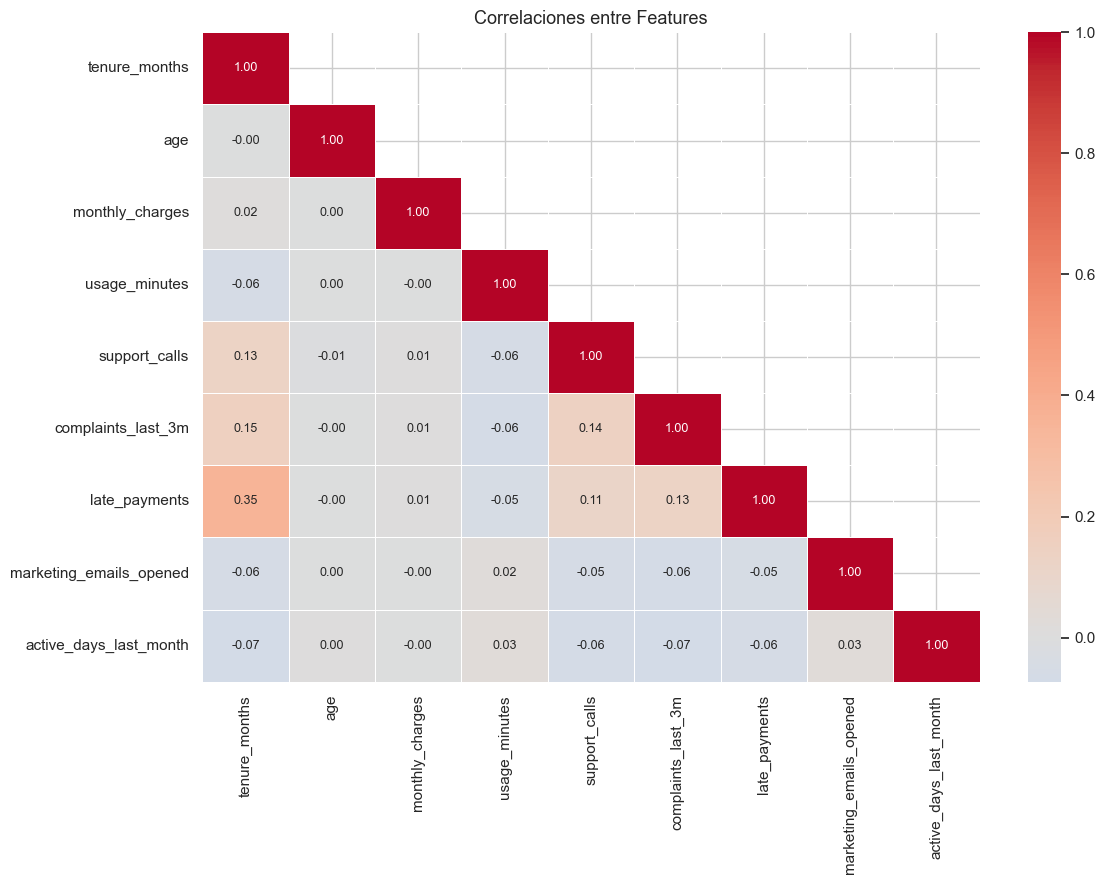

✓ Sin multicolinealidad fuerte entre features (r > 0.5).


In [20]:
# Matriz de correlaciones completa
corr_matrix = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.4, annot_kws={'size': 9})
ax.set_title('Correlaciones entre Features', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares con alta correlación (multicolinealidad)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.5:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

if high_corr:
    print('Pares con correlación > 0.5:')
    for a, b, v in high_corr:
        print(f'  {a} ↔ {b}: {v}')
else:
    print('✓ Sin multicolinealidad fuerte entre features (r > 0.5).')

## 9. Hallazgos y decisiones de diseño

> Este bloque es el output principal del EDA — alimenta directamente las decisiones del preprocessing y modelado.

In [21]:
print('=' * 65)
print('HALLAZGOS EDA — CHURN MODEL')
print('=' * 65)

print(f"""
ESTRUCTURA
  - 33,129 observaciones | 3,000 clientes | 48 períodos (2023-01 → 2026-12)
  - Panel no balanceado: clientes con 1 a 48 obs (media ~11)
  - Churn es evento terminal: cada cliente tiene máximo 1 evento

CALIDAD
  - Sin nulos ni duplicados ✓
  - late_payments tiene distribución zero-inflated (no outlier real)
  - marketing_emails_opened tiene valores altos aislados (revisar)

TARGET
  - Churn rate: 8.95% (desbalance moderado, ratio 10:1)
  - Estrategia recomendada: scale_pos_weight, NO oversampling
  - Churn rate estable en el tiempo (~8-9%)

SEÑALES PREDICTIVAS
  - Correlaciones lineales bajas (máx 0.10 — complaints_last_3m)
  - Señales más informativas: support_calls (+39% en churn), complaints_last_3m (+68%)
  - Variables categóricas con diferencias < 1.5pp → bajo poder individual
  - Sin multicolinealidad fuerte entre features

DECISIONES DE DISEÑO (→ Notebook 02)
  [1] SPLIT TEMPORAL: train = hasta 2025-06, val = 2025-07 a 2025-12, test = 2026
      Razón: evitar data leakage en datos de panel
  [2] FEATURE ENGINEERING: lags (1,3,6 meses) de support_calls, complaints, usage
      Razón: correlaciones lineales bajas → relaciones dinámicas en el tiempo
  [3] MODELO BASE: XGBoost con scale_pos_weight=10
      Razón: relaciones no lineales, desbalance moderado
  [4] MÉTRICA PRINCIPAL: AUC-ROC + Precision-Recall curve
      Razón: desbalance de clases, costo de falsos negativos > falsos positivos
  [5] NO winsorizing en late_payments (distribución esperada)
""")
print('=' * 65)

HALLAZGOS EDA — CHURN MODEL

ESTRUCTURA
  - 33,129 observaciones | 3,000 clientes | 48 períodos (2023-01 → 2026-12)
  - Panel no balanceado: clientes con 1 a 48 obs (media ~11)
  - Churn es evento terminal: cada cliente tiene máximo 1 evento

CALIDAD
  - Sin nulos ni duplicados ✓
  - late_payments tiene distribución zero-inflated (no outlier real)
  - marketing_emails_opened tiene valores altos aislados (revisar)

TARGET
  - Churn rate: 8.95% (desbalance moderado, ratio 10:1)
  - Estrategia recomendada: scale_pos_weight, NO oversampling
  - Churn rate estable en el tiempo (~8-9%)

SEÑALES PREDICTIVAS
  - Correlaciones lineales bajas (máx 0.10 — complaints_last_3m)
  - Señales más informativas: support_calls (+39% en churn), complaints_last_3m (+68%)
  - Variables categóricas con diferencias < 1.5pp → bajo poder individual
  - Sin multicolinealidad fuerte entre features

DECISIONES DE DISEÑO (→ Notebook 02)
  [1] SPLIT TEMPORAL: train = hasta 2025-06, val = 2025-07 a 2025-12, test = 202